# Hillik: a consistent High-&ell; likelihood

[``Hillik``](#https://github.com/mtristram/hillik) is a CMB likelihood based on cross-power spectra which can accomodate spectra from different survey (Planck, SPT, ACT) within a common modelisation of the foreground residuals.\
The likelihood is a Gaussian approximation with a signal model including CMB, galactic emissions (dust), poisson noise (from unmasked point sources) and extra-galactic emissions (tSZ, CIB, kSZ, SZxCIB).\
Nuisance parameters (calibration, polar efficiency, T-E-B leakage, ...) are associated to each survey with the exact same treatment as in the original studies.

In [1]:
import MCtools
from getdist import plots, MCSamples
import warnings
warnings.filterwarnings("ignore")
DBdir = "/sps/planck/Users/tristram/Soft/Hillik/chains"
clth = read_cl( "/sps/planck/Users/tristram/Models/planck_base_planck_2018_TTTEEElowllowE.fits")
lth = arange(len(clth[0]))

## Table Of Content
* [Check original likelihood](#Check-original-likelihood)
* [Planck](#PLK)
* [SPT](#SPT)
* [ACT](#ACT)
* [TT](#TT)
* [TE](#TE)
* [EE](#EE)
* [TT+TE+EE](#TT+TE+EE)

## Check original likelihood

In [ ]:
runnames1 = ['hlpTT','spt','actpol']
chains1 = [MCtools.mergeMC( "%s/%s/mcmc" % (DBdir,run), burnin=0.9, nelts=10000) for run in runnames1]
runnames2 = ['hillik_plkTT','hillik_sptTT','hillik_actTT']
chains2 = [MCtools.mergeMC( "%s/%s/mcmc" % (DBdir,run), burnin=0.9, nelts=10000) for run in runnames2]

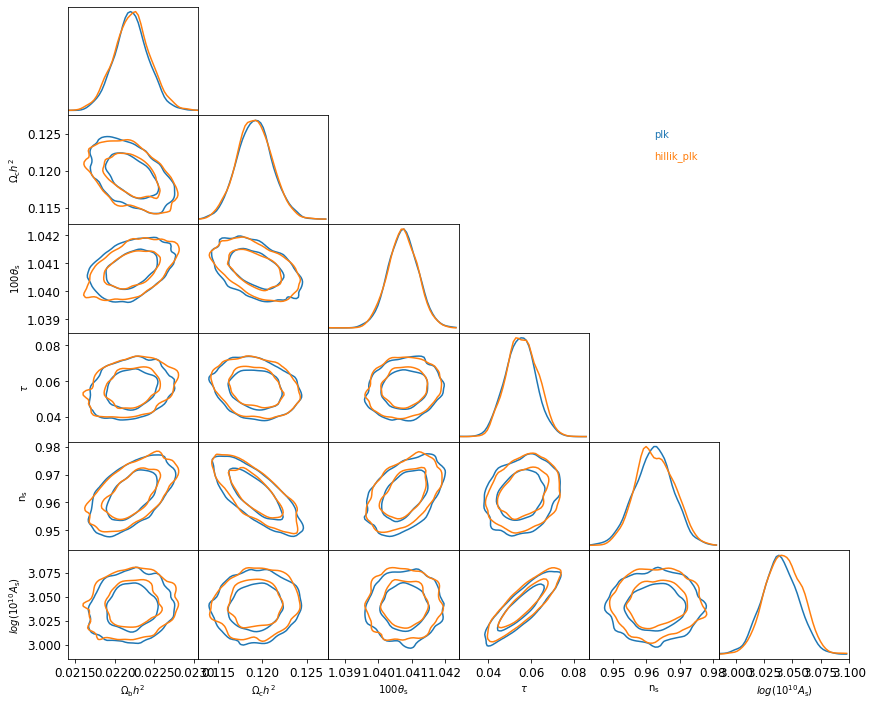

In [7]:
listpar = ['ombh2','omch2','theta','tau','ns','logA']
fig=MCtools.triangle( [chains1[0],chains2[0]], listpar, labels=['plk','hillik_plk'], kde=True)

spt: 406641  313721  308161  472001 
hillik_sptTT: 653091  542542  611573  63966 


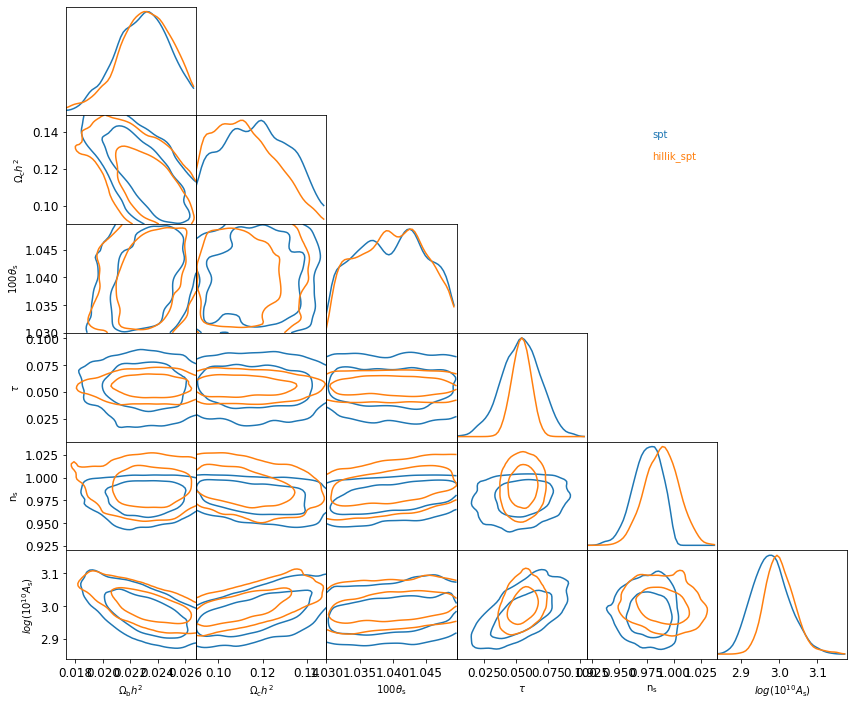

In [2]:
runnames = ['spt','hillik_sptTT']
chains = [MCtools.mergeMC( "%s/%s/mcmc" % (DBdir,run), burnin=0.9, nelts=10000) for run in runnames]
listpar = ['ombh2','omch2','theta','tau','ns','logA']
fig=MCtools.triangle( chains, listpar, labels=['spt','hillik_spt'], kde=True)

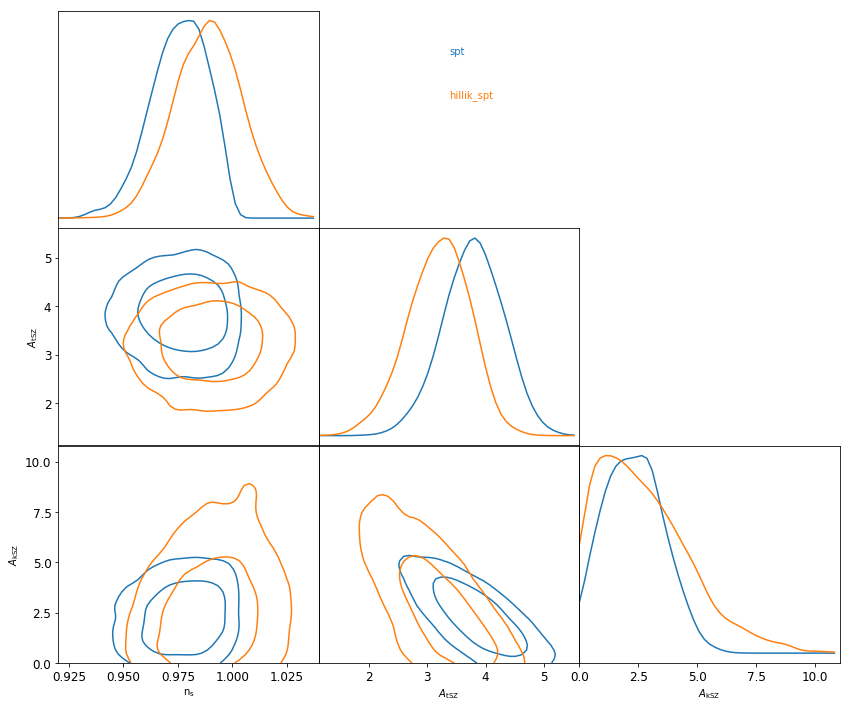

In [5]:
chains[0]['Atsz'] = chains[0]['czero_tsz']
chains[0]['Aksz'] = chains[0]['czero_ksz']
listpar = ['ns','Atsz', 'Aksz']
fig=MCtools.triangle( chains, listpar, labels=['spt','hillik_spt'], kde=True)

spt3g_lowl: 375961  411757  440805  434721 
hillik_spt3gTTTEEE: 459667  319429  315757  251294 


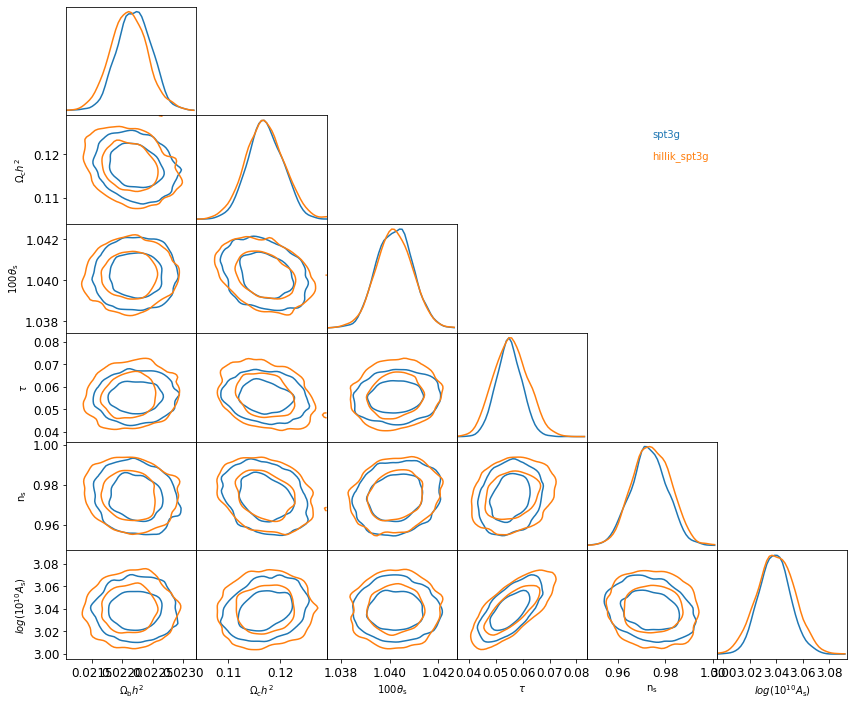

In [22]:
#SPT3G
runnames = ['spt3g_lowl','hillik_spt3gTTTEEE']
chains = [MCtools.mergeMC( "%s/%s/mcmc" % (DBdir,run), burnin=0.9, nelts=10000) for run in runnames]
listpar = ['ombh2','omch2','theta','tau','ns','logA']
fig=MCtools.triangle( chains, listpar, labels=['spt3g','hillik_spt3g'], kde=True)

actpol: 205921  162241  251521  200001 
hillik_actTT: 460333  415760  475876  364420 


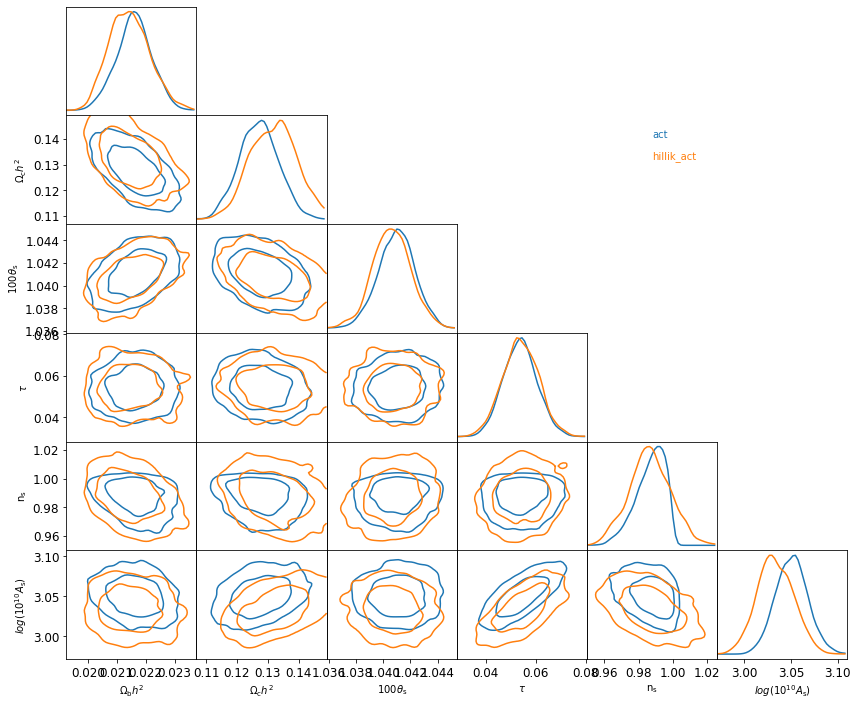

In [6]:
runnames = ['actpol','hillik_actTT']
chains = [MCtools.mergeMC( "%s/%s/mcmc" % (DBdir,run), burnin=0.9, nelts=10000) for run in runnames]
listpar = ['ombh2','omch2','theta','tau','ns','logA']
fig=MCtools.triangle( chains, listpar, labels=['act','hillik_act'], kde=True)

# PLK

hillik_plkTT: 160290  232672  196615  116116 
hillik_plkTE: 245011  242685  191063  167931 
hillik_plkEE: 90161  45441  70001  128001 
hillik_plkTTTEEE: 126413  86891  127736  133289 


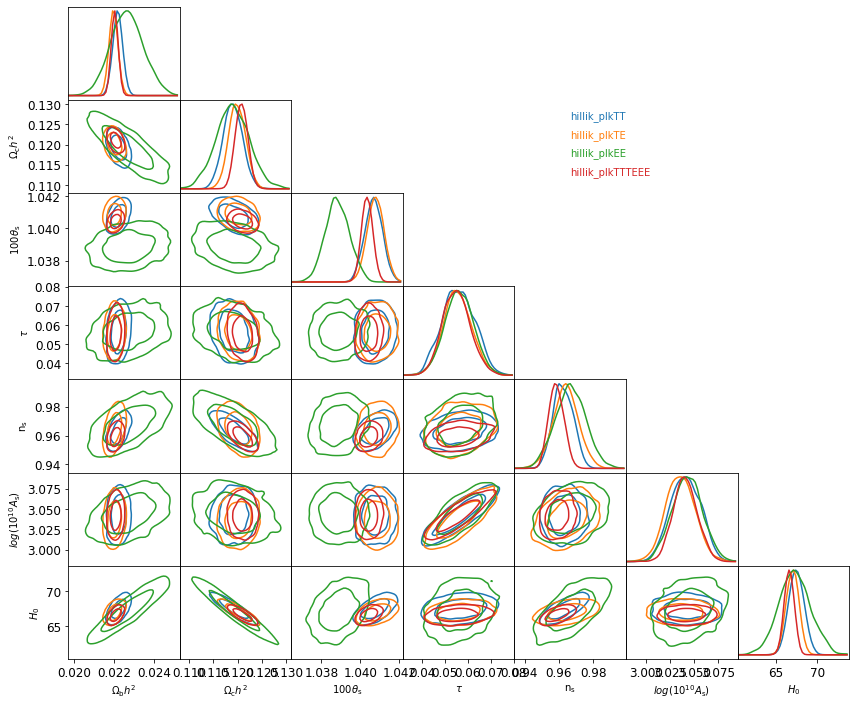

In [2]:
runnames = ['hillik_plkTT','hillik_plkTE','hillik_plkEE','hillik_plkTTTEEE']
chains = [MCtools.mergeMC( "%s/%s/mcmc" % (DBdir,run), burnin=0.9, nelts=10000) for run in runnames]
listpar = ['ombh2','omch2','theta','tau','ns','logA','H0']
fig=MCtools.triangle( chains, listpar, labels=runnames, kde=True)

In [3]:
for par in chains[-1].keys():
    MCtools.PrintMax( chains, par)

minuslogpost    =  5251.419950 +/- 3.253156  |   4954.697300 +/- 3.032862  |   4592.475300 +/- 2.623382  |   15257.109000 +/- 3.526160
cosmomc_theta   =  0.010408 +/- 0.000004  |   0.010409 +/- 0.000004  |   0.010388 +/- 0.000006  |   0.010404 +/- 0.000003
logA            =  3.042451 +/- 0.016011  |   3.036916 +/- 0.014941  |   3.044161 +/- 0.015627  |   3.041922 +/- 0.012314
ns              =  0.962937 +/- 0.005796  |   0.964686 +/- 0.007315  |   0.967340 +/- 0.008891  |   0.958881 +/- 0.004361
ombh2           =  0.022223 +/- 0.000223  |   0.022004 +/- 0.000197  |   0.022676 +/- 0.000822  |   0.022070 +/- 0.000140
omch2           =  0.119227 +/- 0.001945  |   0.120101 +/- 0.001715  |   0.119126 +/- 0.003391  |   0.121022 +/- 0.001237
tau             =  0.056304 +/- 0.007295  |   0.055925 +/- 0.006105  |   0.056732 +/- 0.006290  |   0.055542 +/- 0.005911
A_planck        =  1.000523 +/- 0.002466  |   1.000755 +/- 0.002539  |   1.000639 +/- 0.002405  |   1.001007 +/- 0.002382
cal_PLK_100

# SPT

hillik_sptTT: 653091  542542  611573  63966 
hillik_sptTE: 64545  42156  48229  36474 
hillik_sptEE: 66464  23840  22054  29079 
hillik_sptTTTEEE: 23873  64368  30480  29321 
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


<Figure size 720x720 with 0 Axes>

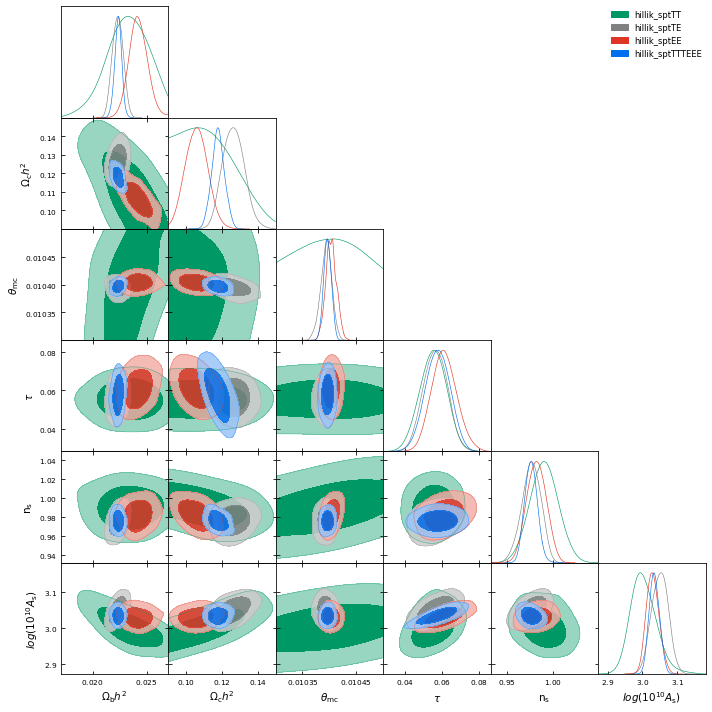

In [15]:
listpar = ['ombh2','omch2','cosmomc_theta','tau','ns','logA']
runnames = ['hillik_sptTT','hillik_sptTE','hillik_sptEE','hillik_sptTTTEEE']
support = {'ombh2':(0.017,0.027),'omch2':(0.09,0.15),'cosmomc_theta':(0.0103,0.0105),'tau':(0.01,0.15),'ns':(0.9,1.1),'logA':(2.6,3.5)}
labels = [MCtools.parname.get(p,p).replace('$','') for p in listpar]
chains = [MCtools.mergeMC( "%s/%s/mcmc" % (DBdir,run), burnin=0.9) for run in runnames]
samples = [MCSamples( samples=[chain[p] for p in listpar], names=listpar, labels=labels, ranges=support) for chain in chains]
g = plots.getSinglePlotter(width_inch=10, ratio=1)
g.triangle_plot(samples, listpar, filled = True, legend_labels = runnames,legend_loc = 'upper right')

hillik_spt3gTT_tauprior: 48593  33206  28424  74795 
hillik_spt3gTE_tauprior: 26667  32899  29795  31846 
hillik_spt3gEE_tauprior: 28720  34898  36031  75781 
hillik_spt3gTTTEEE: 161542  105578  165740  133209 
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


<Figure size 720x720 with 0 Axes>

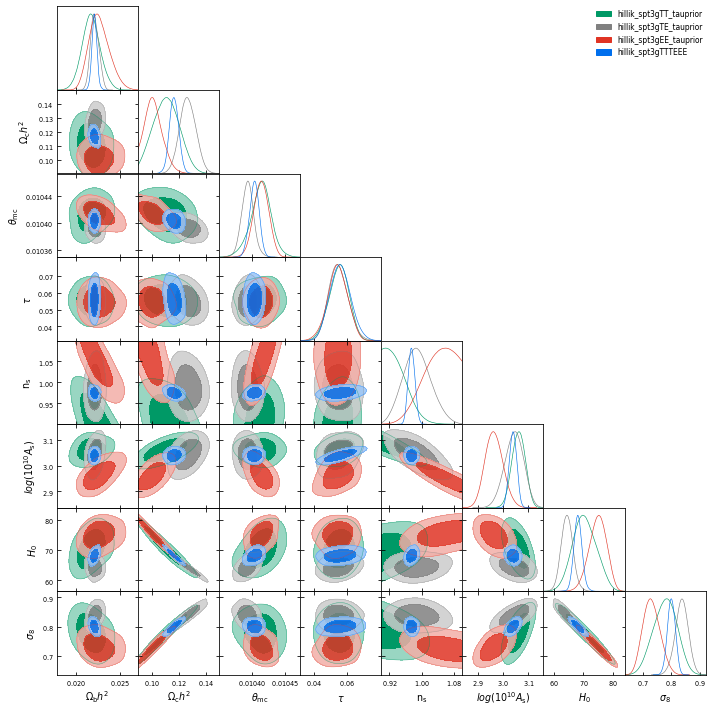

In [2]:
#SPT3G
listpar = ['ombh2','omch2','cosmomc_theta','tau','ns','logA','H0','sigma8']
runnames = ['hillik_spt3gTT_tauprior','hillik_spt3gTE_tauprior','hillik_spt3gEE_tauprior','hillik_spt3gTTTEEE']
support = {'ombh2':(0.017,0.027),'omch2':(0.09,0.15),'cosmomc_theta':(0.0103,0.0105),'tau':(0.01,0.15),'ns':(0.9,1.1),'logA':(2.6,3.5)}
labels = [MCtools.parname.get(p,p).replace('$','') for p in listpar]
chains = [MCtools.mergeMC( "%s/%s/mcmc" % (DBdir,run), burnin=0.9) for run in runnames]
samples = [MCSamples( samples=[chain[p] for p in listpar], names=listpar, labels=labels, ranges=support) for chain in chains]
g = plots.getSinglePlotter(width_inch=10, ratio=1)
g.triangle_plot(samples, listpar, filled = True, legend_labels = runnames,legend_loc = 'upper right')

In [8]:
for par in chains[-1].keys():
    MCtools.PrintMax( chains, par, fmt='8.6f')

minuslogpost    =  408.572960 +/- 3.596107  |   353.754690 +/- 2.968514  |   205.111850 +/- 2.491850  |   985.607340 +/- 3.739003
cosmomc_theta   =  0.010414 +/- 0.000019  |   0.010394 +/- 0.000010  |   0.010403 +/- 0.000009  |   0.010402 +/- 0.000007
logA            =  3.021224 +/- 0.021481  |   3.059802 +/- 0.022131  |   3.030353 +/- 0.018196  |   3.041252 +/- 0.014224
ns              =  0.989925 +/- 0.014387  |   0.979321 +/- 0.010574  |   0.972648 +/- 0.010414  |   0.973984 +/- 0.008819
ombh2           =  0.020421 +/- 0.000883  |   0.022272 +/- 0.000474  |   0.024273 +/- 0.000819  |   0.022060 +/- 0.000309
omch2           =  0.108455 +/- 0.009023  |   0.127058 +/- 0.005981  |   0.106291 +/- 0.005933  |   0.117006 +/- 0.003505
tau             =  0.054862 +/- 0.007419  |   0.056497 +/- 0.006414  |   0.060205 +/- 0.007099  |   0.056649 +/- 0.006992
A_planck        =  1.000164 +/- 0.002507  |   1.000244 +/- 0.002478  |            --            |   1.000304 +/- 0.002448
cal_SPT3G_T90   

hillik_spt3gTT: 285560  325530  282964  475487 
hillik_sptTT: 653091  542542  611573 
Removed no burn in
Removed no burn in


<Figure size 720x720 with 0 Axes>

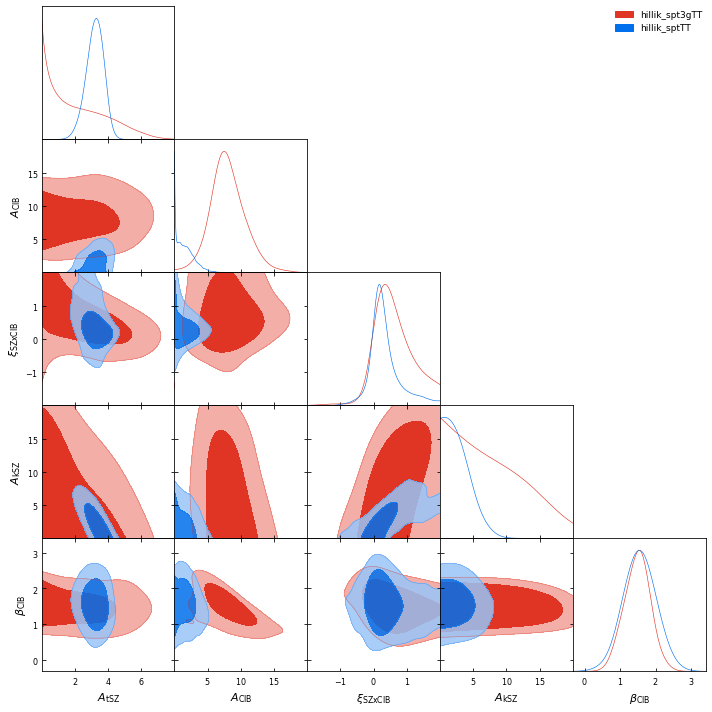

In [4]:
#SPThiell v.s. SPT3G
listpar = ['Atsz','Acib','xi','Aksz','beta_cib']
runnames = ['hillik_spt3gTT','../chains_preSPT3G/hillik_sptTT']
support = {'xi':(-2,2),'Atsz':(0.,8.),'Acib':(0.,20.),'Aksz':(0.,20.)}
labels = [MCtools.parname.get(p,p).replace('$','') for p in listpar]
chains = [MCtools.mergeMC( "%s/%s/mcmc" % (DBdir,run), burnin=-20000, num=(1,2,3) if 'sptTT' in run else []) for run in runnames]
samples = [MCSamples( samples=[chain[p] for p in listpar], names=listpar, labels=labels, ranges=support) for chain in chains]
g = plots.getSinglePlotter(width_inch=10, ratio=1)
g.triangle_plot(samples, listpar, filled = True, legend_labels = [os.path.basename(r) for r in runnames],legend_loc = 'upper right')

# ACT

hillik_actTT: 460333  415760  475876  364420 
hillik_actTE: 62788  55419  62153  40016 
hillik_actEE: 38637  30828  34520  52707 
hillik_actTTTEEE: 59100  53686  55065  56822 


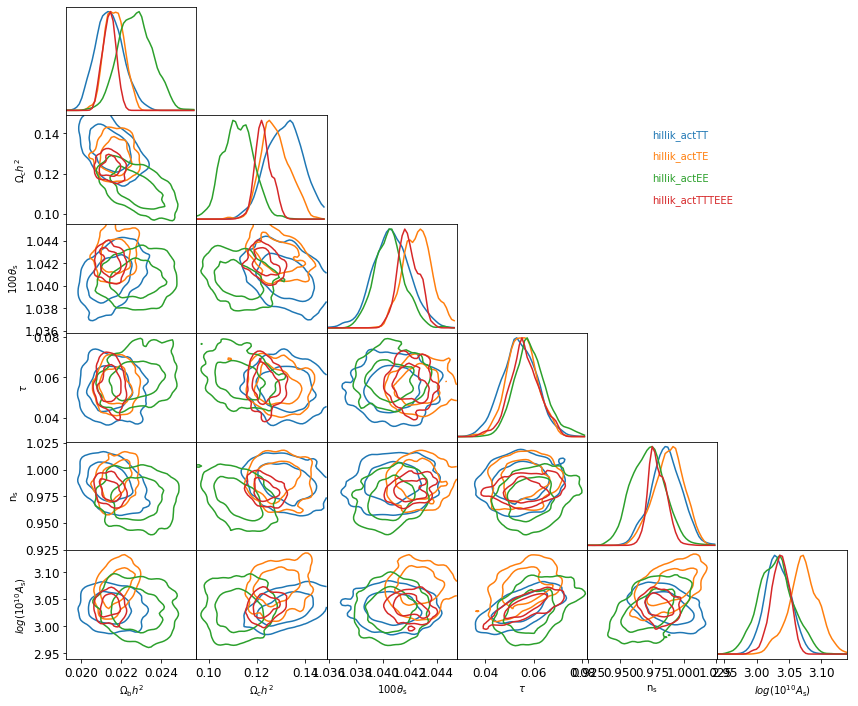

In [16]:
runnames = ['hillik_actTT','hillik_actTE','hillik_actEE','hillik_actTTTEEE']
chains = [MCtools.mergeMC( "%s/%s/mcmc" % (DBdir,run), burnin=0.9, nelts=20000) for run in runnames]
listpar = ['ombh2','omch2','theta','tau','ns','logA']
fig=MCtools.triangle( chains, listpar, labels=runnames, kde=True)

hillik_actTT: 460333  415760  475876  364420 
hillik_actTE: 62870  55499  62277  40071 
hillik_actEE: 38670  30868  34556  52755 
hillik_actTTTEEE: 59204  53803  55148  56941 
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


<Figure size 720x720 with 0 Axes>

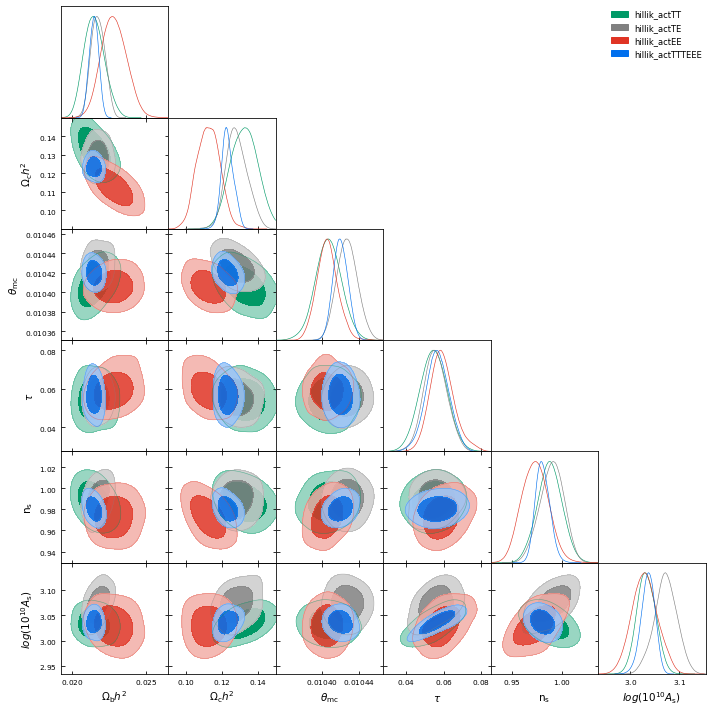

In [17]:
listpar = ['ombh2','omch2','cosmomc_theta','tau','ns','logA']
runnames = ['hillik_actTT','hillik_actTE','hillik_actEE','hillik_actTTTEEE']
support = {'ombh2':(0.017,0.027),'omch2':(0.09,0.15),'cosmomc_theta':(0.0103,0.0105),'tau':(0.01,0.15),'ns':(0.9,1.1),'logA':(2.6,3.5)}
labels = [MCtools.parname.get(p,p).replace('$','') for p in listpar]
chains = [MCtools.mergeMC( "%s/%s/mcmc" % (DBdir,run), burnin=0.9) for run in runnames]
samples = [MCSamples( samples=[chain[p] for p in listpar], names=listpar, labels=labels, ranges=support) for chain in chains]
g = plots.getSinglePlotter(width_inch=10, ratio=1)
g.triangle_plot(samples, listpar, filled = True, legend_labels = runnames,legend_loc = 'upper right')

# TT

hillik_plkTT: 160290  232672  196615  116116 
hillik_actTT: 460333  415760  475876  364420 
hillik_sptTT: 653091  542542  611573  63966 
hillik_plksptact_TT: 880813  1017840  939259  693479 


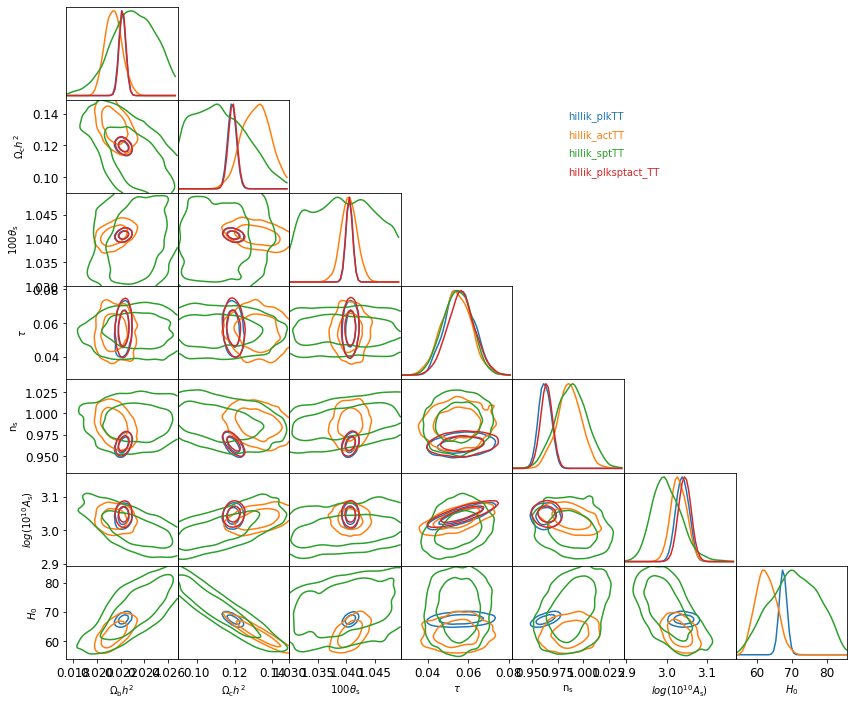

In [2]:
runnames = ['hillik_plkTT','hillik_actTT','hillik_sptTT','hillik_plksptact_TT']
chains = [MCtools.mergeMC( "%s/%s/mcmc" % (DBdir,run), burnin=0.9, nelts=10000) for run in runnames]
listpar = ['ombh2','omch2','theta','tau','ns','logA','H0']
fig=MCtools.triangle( chains, listpar, labels=runnames, kde=True)

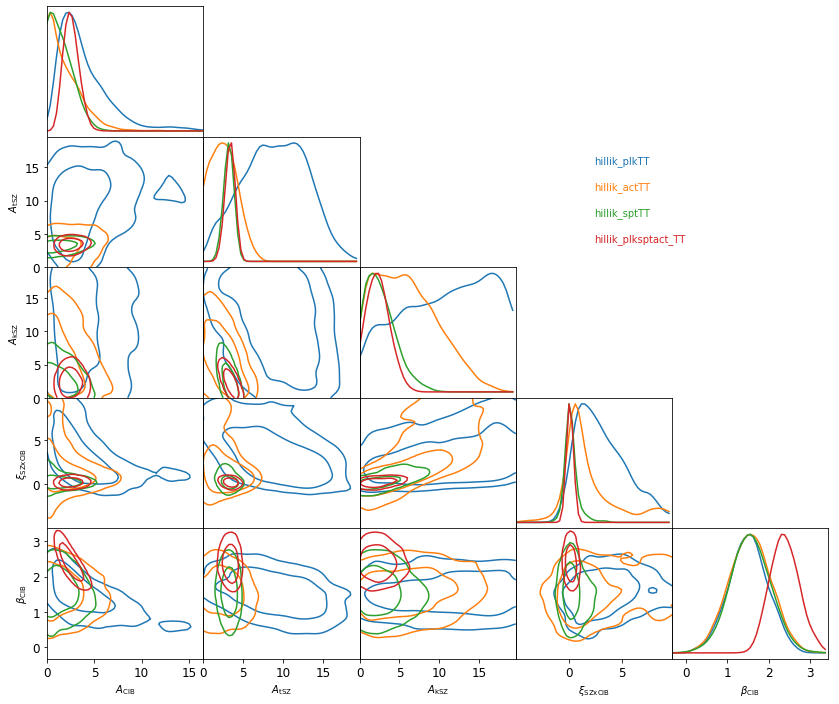

In [19]:
#extra-galactic fg
listpar = ['Acib','Atsz','Aksz','xi', 'beta_cib']
fig=MCtools.triangle( chains, listpar, labels=runnames, kde=True)

# TE

hillik_plkTE: 175477  174474  147016  126182 
hillik_actTE: 63148  55666  62635  40384 
hillik_sptTE: 65080  42544  48603  36850 
hillik_plksptact_TE: 774802  666347  716726  784353 


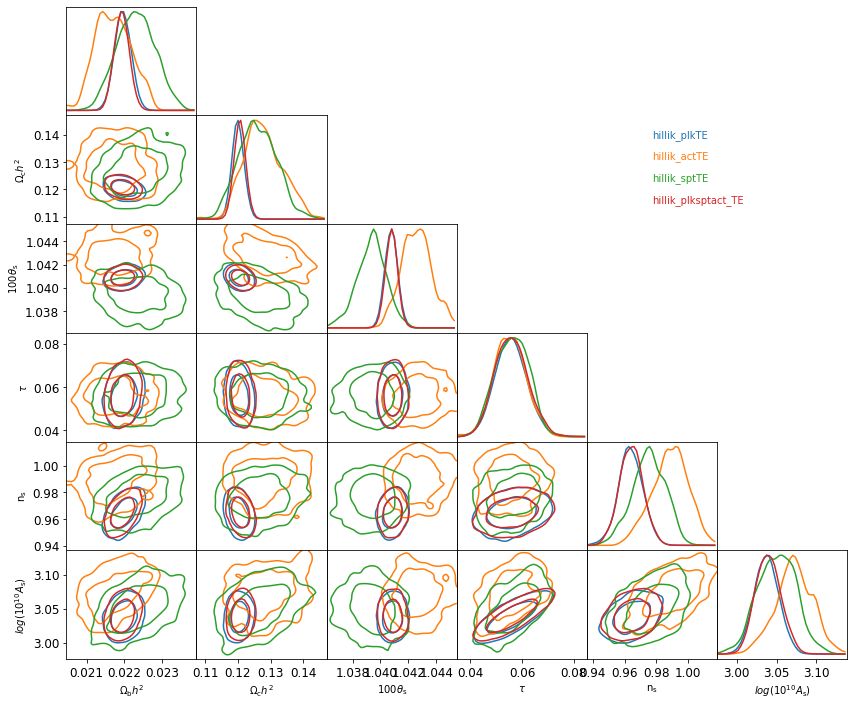

In [20]:
runnames = ['hillik_plkTE','hillik_actTE','hillik_sptTE','hillik_plksptact_TE']
chains = [MCtools.mergeMC( "%s/%s/mcmc" % (DBdir,run), burnin=0.9, nelts=10000) for run in runnames]
listpar = ['ombh2','omch2','theta','tau','ns','logA']
fig=MCtools.triangle( chains, listpar, labels=runnames, kde=True)

# EE

hillik_plkEE: 90161  45441  70001  128001 
hillik_actEE: 38927  31048  34771  53111 
hillik_sptEE: 67072  24090  22248  29255 
hillik_plksptact_EE: 418746  964517  524601  429201 


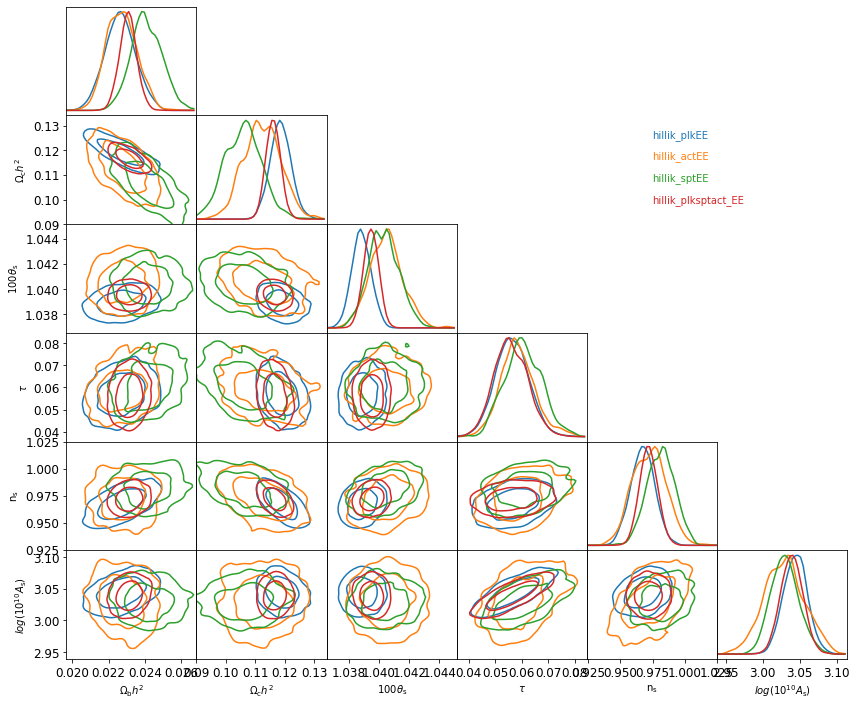

In [21]:
runnames = ['hillik_plkEE','hillik_actEE','hillik_sptEE','hillik_plksptact_EE']
chains = [MCtools.mergeMC( "%s/%s/mcmc" % (DBdir,run), burnin=0.9, nelts=10000) for run in runnames]
listpar = ['ombh2','omch2','theta','tau','ns','logA']
fig=MCtools.triangle( chains, listpar, labels=runnames, kde=True)

# TT+TE+EE

hillik_plkTTTEEE: 106290  68065  108437  110008 
hillik_actTTTEEE: 133916  141867  131298  139387 
hillik_sptTTTEEE: 67820  145337  80531  84857 
hillik_plksptact_TTTEEE: 100001  100001  100001  100001 


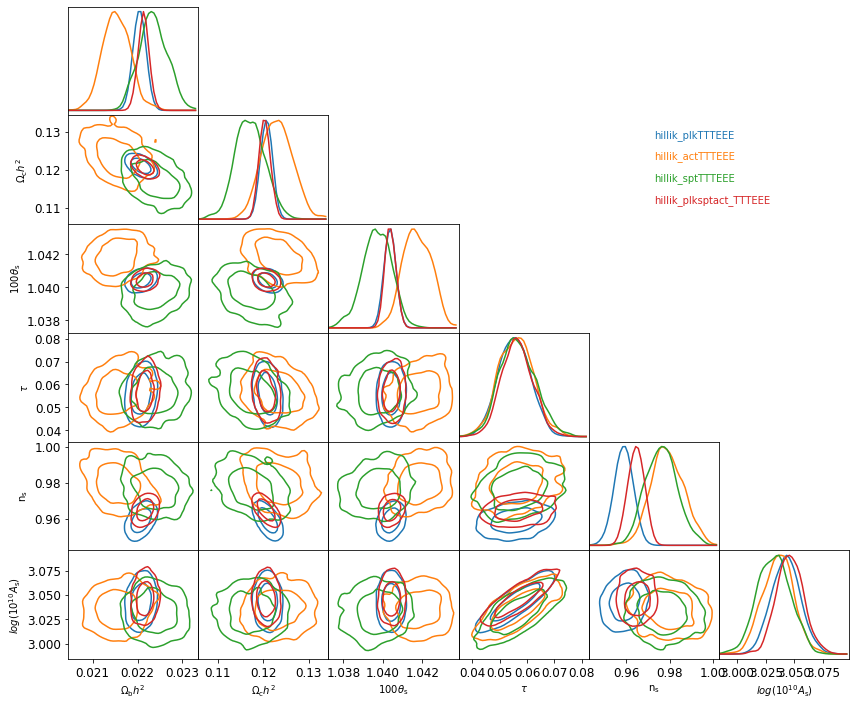

In [7]:
runnames = ['hillik_plkTTTEEE','hillik_actTTTEEE','hillik_sptTTTEEE','hillik_plksptact_TTTEEE']
chains = [MCtools.mergeMC( "%s/%s/mcmc" % (DBdir,run), burnin=0.8, nelts=10000) for run in runnames]
listpar = ['ombh2','omch2','theta','tau','ns','logA']
fig=MCtools.triangle( chains, listpar, labels=runnames, kde=True)

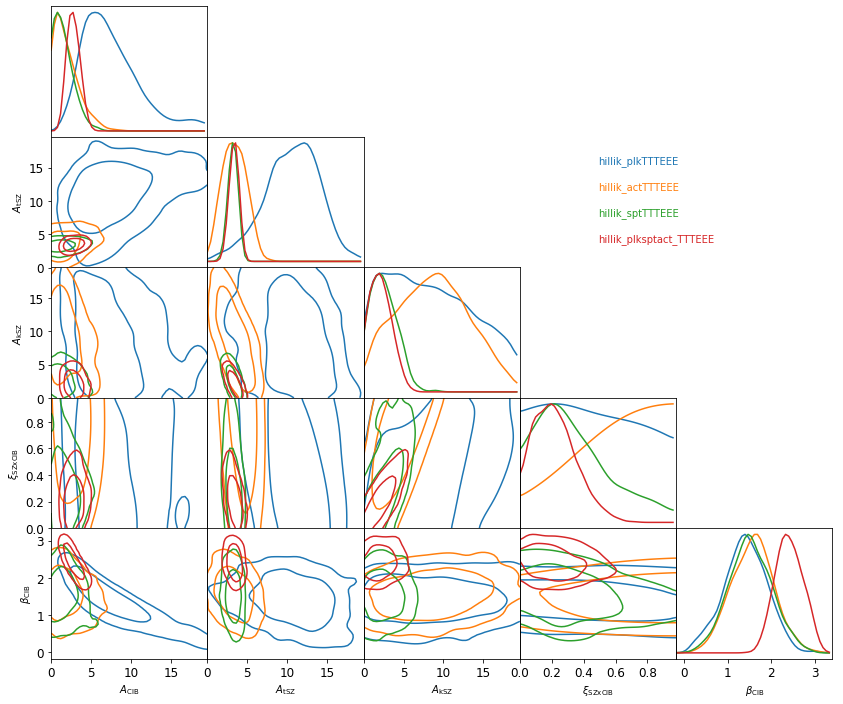

In [8]:
#extra-galactic fg
listpar = ['Acib','Atsz','Aksz','xi', 'beta_cib']
fig=MCtools.triangle( chains, listpar, labels=runnames, kde=True, rge={'xi':(0,1)})